# Credit Risk: Predict probability of default (PD) and classify high-risk loans

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===== BASIC INFO =====
   Loan_ID Customer_Type  Annual_Income  Debt_to_Income  \
0        1     Corporate        2676791            0.47   
1        2        Retail        2740108            0.15   
2        3     Corporate        4863177            0.20   
3        4     Corporate        3383597            0.19   
4        5        Retail          95953            0.62   

   Credit_History_Length  Loan_Amount  Interest_Rate  Loan_Term_Months  \
0                     15       399593          13.39                36   
1                     23       825131          12.80                36   
2                     15        83686           6.09                48   
3                      5        77661           5.05                48   
4                     21       578535          11.02                24   

   Past_Default    PD  
0             0  0.22  

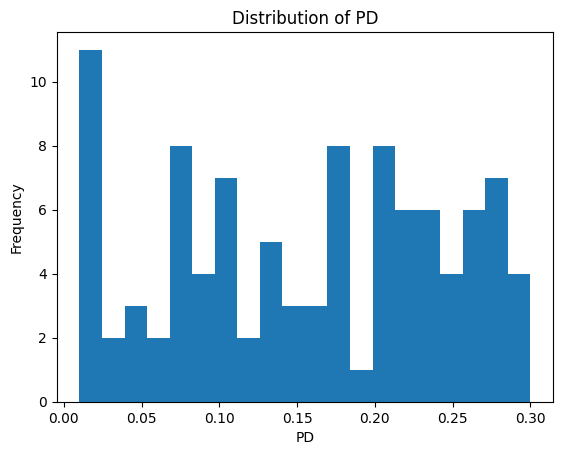


===== QUICK INSIGHTS =====
Average Loan Amount: 509767.28
Average Interest Rate: 9.0689
Average PD: 0.1572
   Loan_ID  Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0        1        2676791            0.47                     15       399593   
1        2        2740108            0.15                     23       825131   
2        3        4863177            0.20                     15        83686   
3        4        3383597            0.19                      5        77661   
4        5          95953            0.62                     21       578535   

   Interest_Rate  Loan_Term_Months  Past_Default    PD  Monthly_Rate  \
0          13.39                36             0  0.22      0.011158   
1          12.80                36             0  0.02      0.010667   
2           6.09                48             0  0.18      0.005075   
3           5.05                48             0  0.07      0.004208   
4          11.02                24           

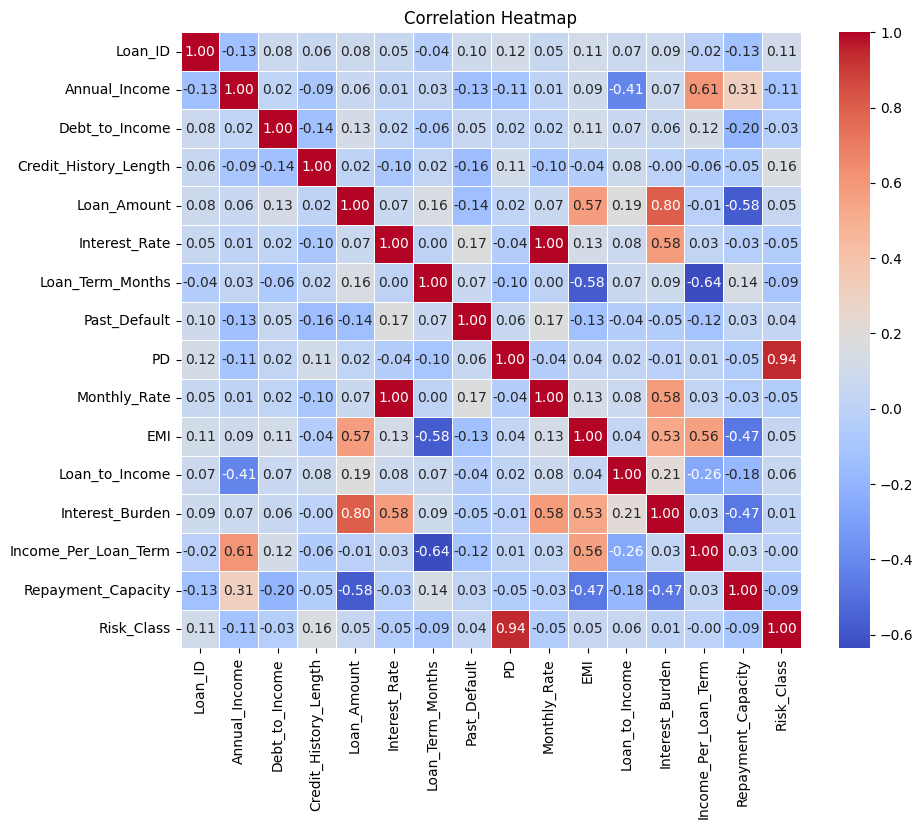


===== PD REGRESSION MODEL PERFORMANCE =====

--- RandomForest ---
MAE: 0.07625545093463473
R2: 0.11426548843477091

--- XGBoost ---
MAE: 0.06114947809278966
R2: 0.3810191840648869

===== CLASSIFICATION =====

--- RandomForest ---
Accuracy: 0.45
ROC AUC: 0.7074434389140272
Log Loss: 1.057551055045603

--- XGBoost ---
Accuracy: 0.4
ROC AUC: 0.6159502262443439
Log Loss: 1.5683985187600002


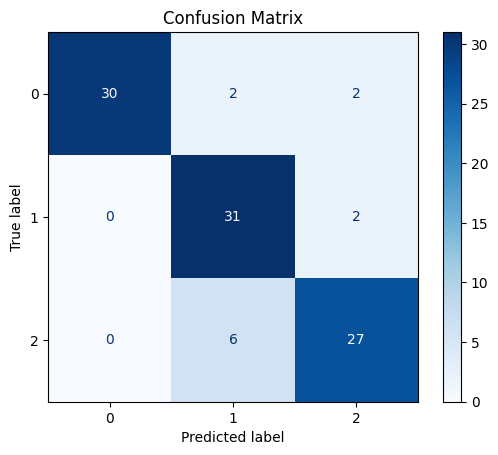

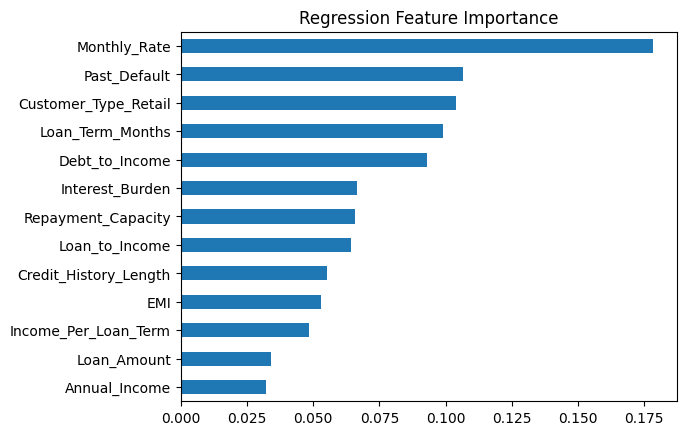

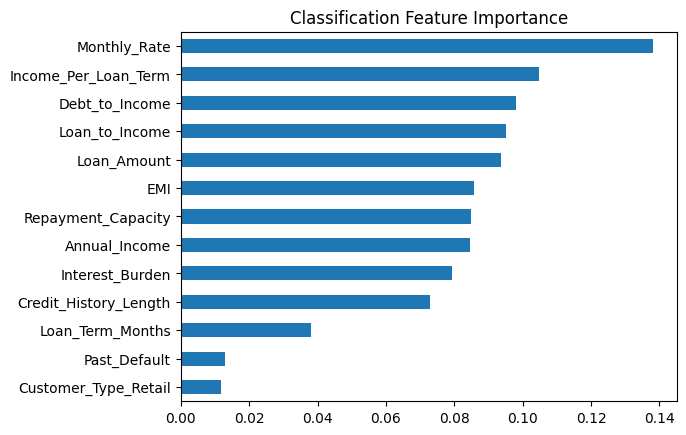


Generating SHAP plots...


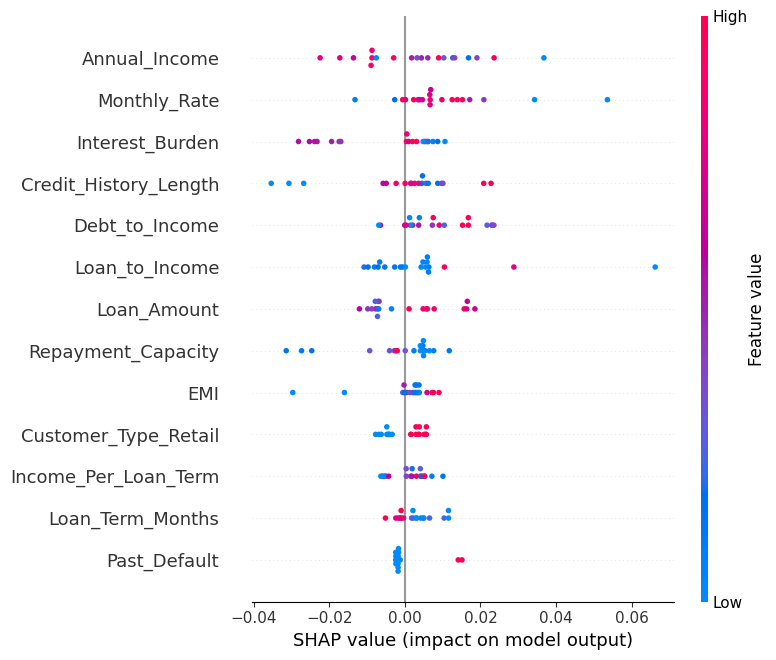

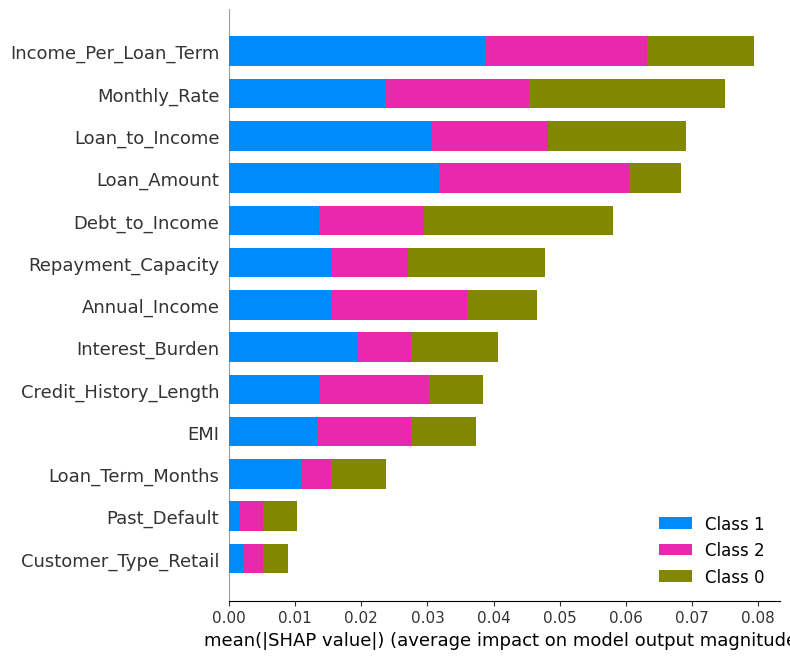


===== SUMMARY =====
Rejected: 14
Review: 23
Approved: 63

===== TOP REJECTED LOANS =====
    Loan_ID  Annual_Income  Debt_to_Income  Credit_History_Length  \
22       23        2213151            0.52                     24   
85       86        1367682            0.28                     24   
93       94        1721738            0.52                      3   
65       66        1231193            0.88                     21   
91       92        4472987            0.52                      8   
89       90        2645075            0.19                      4   
63       64        2416488            0.58                     19   
43       44        1642818            0.66                     11   
94       95        2938873            0.78                     20   
39       40        1256607            0.57                      6   

    Loan_Amount  Interest_Rate  Loan_Term_Months  Past_Default    PD  \
22       639474           3.62                48             0  0.23   
85    

In [114]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, roc_auc_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import shap


# =========================================
# 2. LOAD DATA
# =========================================
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/ml-for-finance-project/loan_portfolio.csv'
df = pd.read_csv(file_path)

print("\n===== BASIC INFO =====")
print(df.head())


# =========================================
# 3. DATA UNDERSTANDING
# =========================================
print("\n===== DATASET DESCRIPTION =====")
print(df.describe(include='all'))

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


# =========================================
# 4. OUTLIER ANALYSIS (IQR METHOD)
# =========================================
numeric_cols = df.select_dtypes(include=np.number).columns

print("\n===== OUTLIER CHECK =====")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if not outliers.empty:
        print(f"{col}: Outliers at rows {outliers.index.tolist()}")
    else:
        print(f"{col}: No significant outliers")


# =========================================
# 5. PD DISTRIBUTION
# =========================================
print("\n===== PD DISTRIBUTION =====")

plt.figure()
plt.hist(df['PD'], bins=20)
plt.title('Distribution of PD')
plt.xlabel('PD')
plt.ylabel('Frequency')
plt.show()


# =========================================
# 6. QUICK INSIGHTS
# =========================================
print("\n===== QUICK INSIGHTS =====")
print("Average Loan Amount:", df['Loan_Amount'].mean())
print("Average Interest Rate:", df['Interest_Rate'].mean())
print("Average PD:", df['PD'].mean())


# =========================================
# 7. FEATURE ENGINEERING
# =========================================
df_mod = df.copy()

df_mod['Monthly_Rate'] = df_mod['Interest_Rate'] / (12 * 100)

df_mod['EMI'] = np.where(
    df_mod['Monthly_Rate'] == 0,
    df_mod['Loan_Amount'] / df_mod['Loan_Term_Months'],
    (
        df_mod['Loan_Amount'] *
        df_mod['Monthly_Rate'] *
        (1 + df_mod['Monthly_Rate']) ** df_mod['Loan_Term_Months']
    ) /
    ((1 + df_mod['Monthly_Rate']) ** df_mod['Loan_Term_Months'] - 1)
)

df_mod['Loan_to_Income'] = df_mod['Loan_Amount'] / (df_mod['Annual_Income'] + 1)
df_mod['Interest_Burden'] = df_mod['Loan_Amount'] * df_mod['Interest_Rate']
df_mod['Income_Per_Loan_Term'] = df_mod['Annual_Income'] / (df_mod['Loan_Term_Months'] + 1)
df_mod['Repayment_Capacity'] = df_mod['Annual_Income'] / (df_mod['EMI'] * 12 + 1)

df_mod = pd.get_dummies(df_mod, drop_first=True)

df_mod['Risk_Class'] = pd.qcut(df_mod['PD'], 3, labels=[0,1,2]).astype(int)

print(df_mod.head())


# =========================================
# 8. CORRELATION ANALYSIS
# =========================================
print("\n===== CORRELATION MATRIX =====")

numeric_cols = df_mod.select_dtypes(include=np.number).columns
corr = df_mod[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


# =========================================
# 9. FEATURE SELECTION
# =========================================
features = [
    col for col in df_mod.columns
    if col not in ['Loan_ID', 'PD', 'High_Risk', 'Interest_Rate', 'Risk_Class']
]

X = df_mod[features]
y = df_mod['PD']


# =========================================
# 10. TRAIN-TEST SPLIT (REGRESSION)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================================
# 11. REGRESSION MODELS
# =========================================
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=3, random_state=42)
xgb_reg = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)

rf_reg.fit(X_train, y_train)
xgb_reg.fit(X_train, y_train)


# =========================================
# 12. REGRESSION EVALUATION
# =========================================
def evaluate_regression(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

print("\n===== PD REGRESSION MODEL PERFORMANCE =====")
evaluate_regression("RandomForest", y_test, rf_reg.predict(X_test))
evaluate_regression("XGBoost", y_test, xgb_reg.predict(X_test))


# =========================================
# 13. CLASSIFICATION
# =========================================
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

y_risk = df_mod['Risk_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)

rf_clf.fit(X_train, y_train)
xgb_clf.fit(X_train, y_train)


# =========================================
# 14. CLASSIFICATION EVALUATION
# =========================================
def evaluate_classification(name, y_true, y_pred, y_prob):
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'))
    print("Log Loss:", log_loss(y_true, y_prob))

print("\n===== CLASSIFICATION =====")
evaluate_classification("RandomForest",
                        y_test,
                        rf_clf.predict(X_test),
                        rf_clf.predict_proba(X_test))

evaluate_classification("XGBoost",
                        y_test,
                        xgb_clf.predict(X_test),
                        xgb_clf.predict_proba(X_test))


# =========================================
# 15. FINAL MODELS
# =========================================
final_reg_model = xgb_reg
final_clf_model = rf_clf


# =========================================
# 16. PREDICTIONS
# =========================================
df_mod['Predicted_PD'] = final_reg_model.predict(X)
df_mod['Predicted_Risk_Class'] = final_clf_model.predict(X)


# =========================================
# 17. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_risk, final_clf_model.predict(X))
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


# =========================================
# 18. FEATURE IMPORTANCE
# =========================================
def plot_importance(model, title):
    importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    importance.plot(kind='barh')
    plt.title(title)
    plt.show()

plot_importance(final_reg_model, "Regression Feature Importance")
plot_importance(final_clf_model, "Classification Feature Importance")


# =========================================
# 19. SHAP EXPLAINABILITY
# =========================================
print("\nGenerating SHAP plots...")

explainer = shap.Explainer(final_reg_model, X_train.astype(float))
shap.summary_plot(explainer(X_test.astype(float)), X_test)

explainer = shap.Explainer(final_clf_model, X_train.astype(float))
shap.summary_plot(explainer(X_test.astype(float)), X_test)


# =========================================
# 20. BUSINESS LOGIC
# =========================================
df_mod['Expected_Profit'] = (
    (1 - df_mod['Predicted_PD']) *
    df_mod['Loan_Amount'] *
    df_mod['Interest_Rate']
)

df_mod['Profit_Ratio'] = df_mod['Expected_Profit'] / (df_mod['Loan_Amount'] + 1)


def decision(row):
    if row['Predicted_Risk_Class'] == 2:
        if row['Profit_Ratio'] > 5 and row['Past_Default'] == 0:
            return "Review"
        else:
            return "Reject"

    elif row['Predicted_Risk_Class'] == 1:
        if row['Expected_Profit'] > 10 and row['Past_Default'] == 0:
            return "Approve"
        else:
            return "Review"

    else:
        return "Approve"


df_mod['Decision'] = df_mod.apply(decision, axis=1)


# =========================================
# 21. OUTPUT
# =========================================
rejected_loans = df_mod[df_mod['Decision'] == "Reject"].sort_values(
    by='Predicted_PD', ascending=False
)

review_loans = df_mod[df_mod['Decision'] == "Review"]
approve_loans = df_mod[df_mod['Decision'] == "Approve"]

print("\n===== SUMMARY =====")
print("Rejected:", len(rejected_loans))
print("Review:", len(review_loans))
print("Approved:", len(approve_loans))

print("\n===== TOP REJECTED LOANS =====")
print(rejected_loans.head(10))

# Fraud Detection: Flag anomalous transactions using supervised or unsupervised methods